# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="/Users/anoob/Downloads/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames, skiprows=1)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [3]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

Parameters:


history: Keras History object returned by model.fit()


title: string title for the plot

In [5]:
def plot_history(history, title="Model Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)

    # --- Loss ---
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].set_title('Loss vs Epoch')
    axes[0].legend()
    axes[0].grid(True)

    # --- Accuracy ---
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy vs Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

# --- Prepare the three input sets ---

# Raw inputs only
X_Train_Raw = np.array(Train_Sample[RawNames])
X_Test_Raw  = np.array(Test_Sample[RawNames])

# High-level features only
X_Train_Feat = np.array(Train_Sample[FeatureNames])
X_Test_Feat  = np.array(Test_Sample[FeatureNames])

# Combined
X_Train_All = np.array(Train_Sample[VarNames[1:]])
X_Test_All  = np.array(Test_Sample[VarNames[1:]])

# --- Scale each input set (critical for DNN training stability) ---
# StandardScaler: zero mean, unit variance per feature

def scale(X_tr, X_te):
    scaler = StandardScaler()
    return scaler.fit_transform(X_tr), scaler.transform(X_te)

X_Train_Raw_s,  X_Test_Raw_s  = scale(X_Train_Raw,  X_Test_Raw)
X_Train_Feat_s, X_Test_Feat_s = scale(X_Train_Feat, X_Test_Feat)
X_Train_All_s,  X_Test_All_s  = scale(X_Train_All,  X_Test_All)

Baseline DNN: 3 hidden layers of 300 neurons each.
    Architecture mirrors the SUSY paper's shallow network for comparison.


In [15]:
def build_baseline_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

Training on RAW inputs...
Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7909 - loss: 0.4479 - val_accuracy: 0.7971 - val_loss: 0.4373
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7977 - loss: 0.4367 - val_accuracy: 0.7988 - val_loss: 0.4337
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8001 - loss: 0.4328 - val_accuracy: 0.8009 - val_loss: 0.4303
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8009 - loss: 0.4312 - val_accuracy: 0.8012 - val_loss: 0.4287
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8014 - loss: 0.4300 - val_accuracy: 0.8016 - val_loss: 0.4282
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8020 - loss: 0.4290 - val_accuracy: 0.8007 - val_loss: 0.4301
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8023 - loss: 0.4284 - val_accuracy: 0.8013 - val_loss: 0.4276
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8026 - loss:

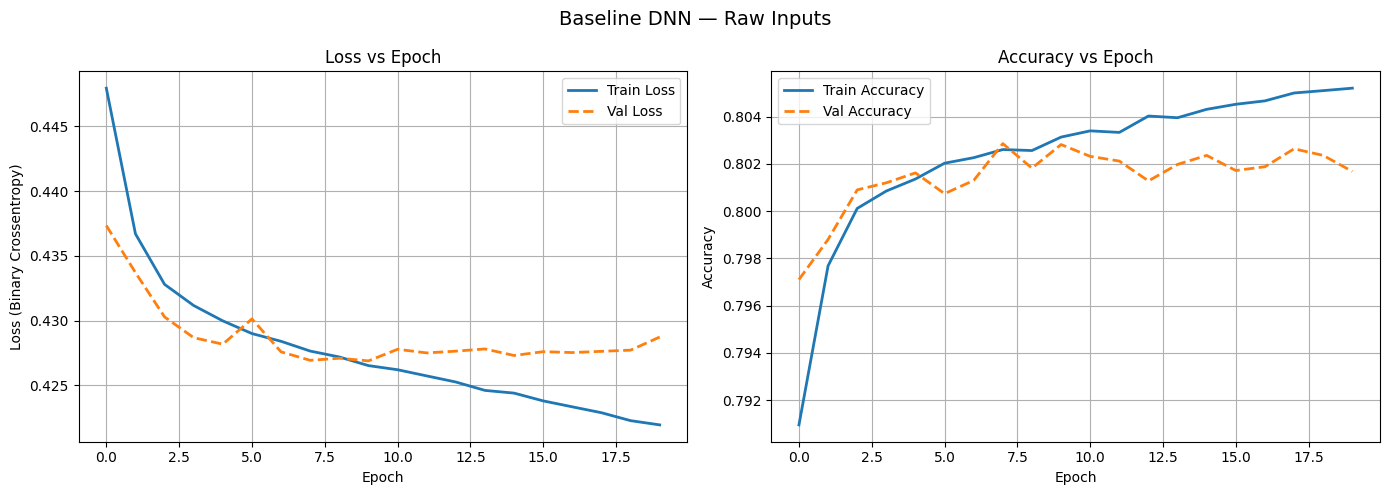

Training on FEATURES...
Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7758 - loss: 0.4762 - val_accuracy: 0.7861 - val_loss: 0.4582
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7854 - loss: 0.4599 - val_accuracy: 0.7902 - val_loss: 0.4533
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7870 - loss: 0.4567 - val_accuracy: 0.7888 - val_loss: 0.4528
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7880 - loss: 0.4549 - val_accuracy: 0.7901 - val_loss: 0.4515
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7890 - loss: 0.4535 - val_accuracy: 0.7900 - val_loss: 0.4515
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7891 - loss: 0.4530 - val_accuracy: 0.7901 - val_loss: 0.4503
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7900 - loss: 0.4515 - val_accuracy: 0.7906 - val_loss: 0.4489
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7903 - loss: 0

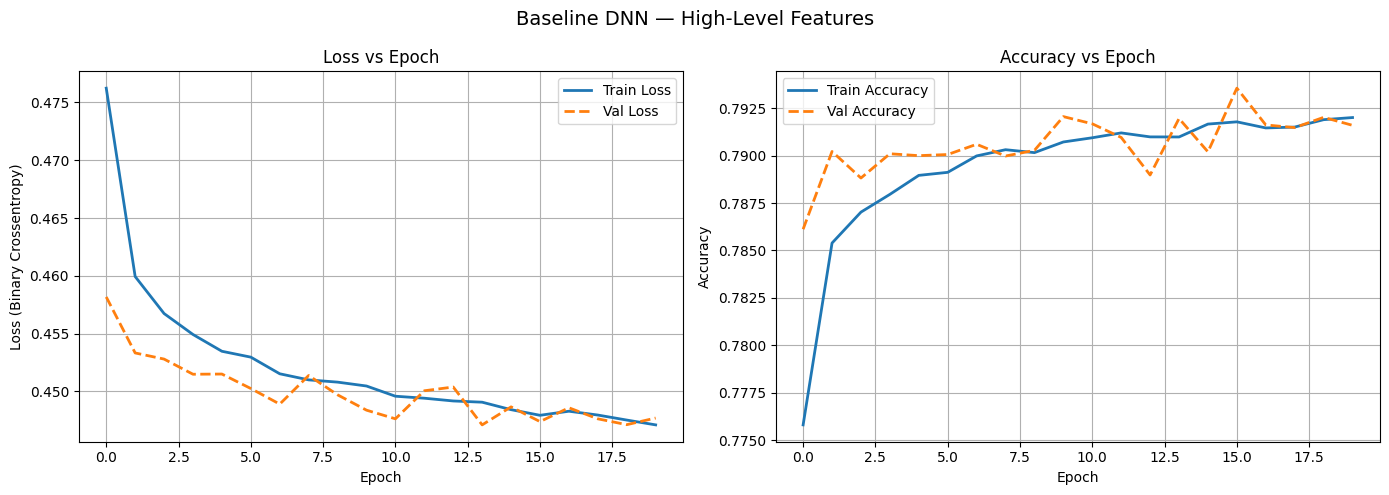

Training on RAW + FEATURES...
Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7962 - loss: 0.4401 - val_accuracy: 0.8005 - val_loss: 0.4299
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8009 - loss: 0.4311 - val_accuracy: 0.8011 - val_loss: 0.4295
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8019 - loss: 0.4292 - val_accuracy: 0.8031 - val_loss: 0.4271
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8025 - loss: 0.4281 - val_accuracy: 0.8030 - val_loss: 0.4258
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8029 - loss: 0.4273 - val_accuracy: 0.8045 - val_loss: 0.4261
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8030 - loss: 0.4264 - val_accuracy: 0.8033 - val_loss: 0.4255
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8034 - loss: 0.4259 - val_accuracy: 0.8042 - val_loss: 0.4244
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8039 - l

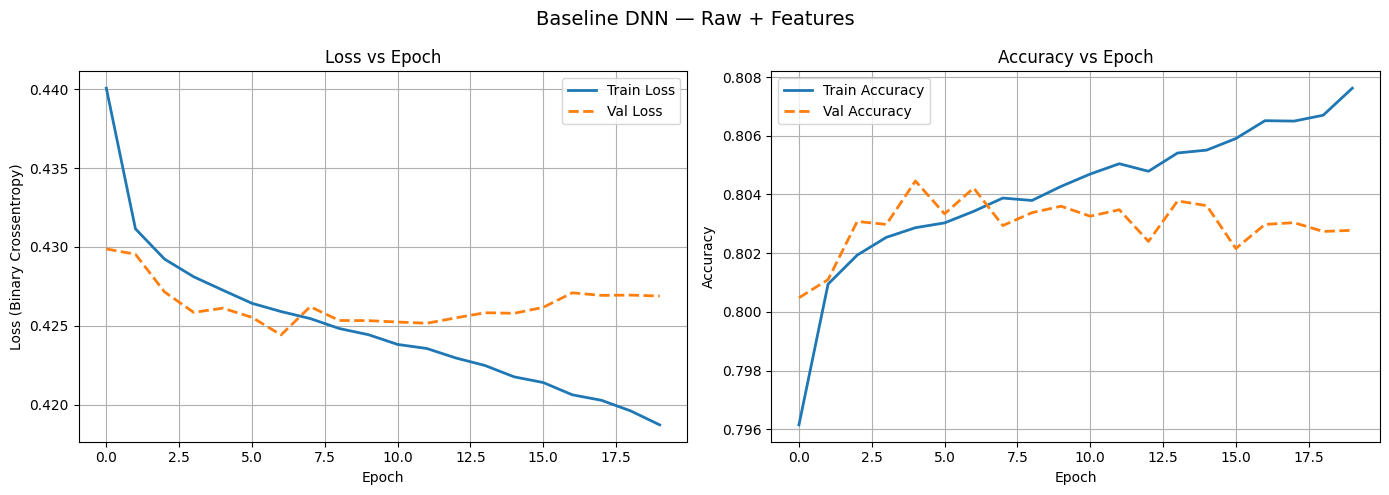

In [17]:
# --- Train all three models ---
EPOCHS = 20
BATCH  = 1024  # larger batches = faster epochs, reasonable for 500k samples

print("Training on RAW inputs...")
model_raw = build_baseline_dnn(len(RawNames))
hist_raw = model_raw.fit(
    X_Train_Raw_s, y_Train,
    validation_data=(X_Test_Raw_s, y_Test),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)
plot_history(hist_raw, title="Baseline DNN — Raw Inputs")

print("Training on FEATURES...")
model_feat = build_baseline_dnn(len(FeatureNames))
hist_feat = model_feat.fit(
    X_Train_Feat_s, y_Train,
    validation_data=(X_Test_Feat_s, y_Test),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)
plot_history(hist_feat, title="Baseline DNN — High-Level Features")

print("Training on RAW + FEATURES...")
model_all = build_baseline_dnn(len(VarNames)-1)
hist_all = model_all.fit(
    X_Train_All_s, y_Train,
    validation_data=(X_Test_All_s, y_Test),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)
plot_history(hist_all, title="Baseline DNN — Raw + Features")

Plots ROC curves and prints AUC for multiple models.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


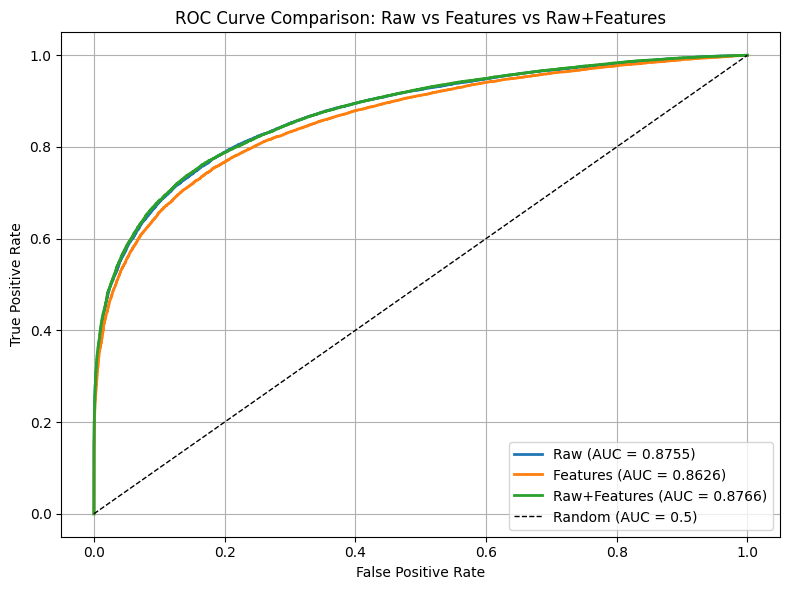

In [18]:
def plot_roc_curves(models_dict, X_tests, y_true):
    plt.figure(figsize=(8, 6))

    for label, model in models_dict.items():
        y_score = model.predict(X_tests[label], batch_size=2048).ravel()
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {roc_auc:.4f})")

    plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison: Raw vs Features vs Raw+Features')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

models_ex2 = {
    "Raw":          model_raw,
    "Features":     model_feat,
    "Raw+Features": model_all,
}
X_tests_ex2 = {
    "Raw":          X_Test_Raw_s,
    "Features":     X_Test_Feat_s,
    "Raw+Features": X_Test_All_s,
}

plot_roc_curves(models_ex2, X_tests_ex2, y_Test)

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [19]:
# We use Raw+Features (all variables) for fair comparison across models.
# Already scaled as X_Train_All_s / X_Test_All_s.

input_dim = len(VarNames) - 1

Model: "Wide_Shallow_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,897 (1.04 MB)

 Trainable params: 272,897 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7932 - loss: 0.4455 - val_accuracy: 0.7996 - val_loss: 0.4316
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7997 - loss: 0.4351 - val_accuracy: 0.8022 - val_loss: 0.4285
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8007 - loss: 0.4331 - val_accuracy: 0.8026 - val_loss: 0.4270
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8013 - loss: 0.4318 - val_accuracy: 0.8027 - val_loss: 0.4270
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8014 - loss: 0.4309 - val_accuracy: 0.8028 - val_loss: 0.4267
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8016 - loss: 0.4305 - val_accuracy: 0.8029 - val_loss: 0.4258
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8020 - loss: 0.4298 - val_accuracy: 0.8029 - val_loss: 0.4261
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8024 - loss: 0.4296 - val_accuracy: 0.

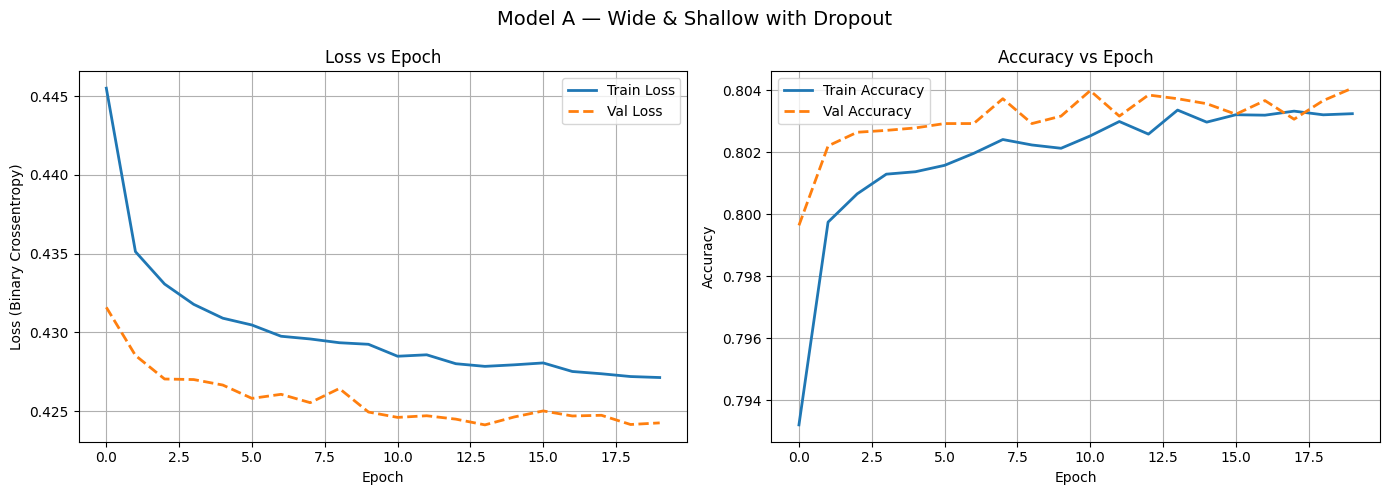

In [20]:
# --- Model A: Wide & Shallow with Dropout ---
# Dropout randomly zeros neurons during training, reducing co-adaptation
# and acting as an ensemble of smaller networks → reduces overfitting.

model_A = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),               # drop 30% of neurons each step
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name="Wide_Shallow_Dropout")

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_A.summary()

hist_A = model_A.fit(
    X_Train_All_s, y_Train,
    validation_data=(X_Test_All_s, y_Test),
    epochs=20, batch_size=1024, verbose=1
)
plot_history(hist_A, title="Model A — Wide & Shallow with Dropout")

Model: "Deep_Narrow_BatchNorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,193 (344.50 KB)

 Trainable params: 86,657 (338.50 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7926 - loss: 0.4467 - val_accuracy: 0.7999 - val_loss: 0.4347
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8000 - loss: 0.4324 - val_accuracy: 0.8021 - val_loss: 0.4327
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8011 - loss: 0.4301 - val_accuracy: 0.8020 - val_loss: 0.4277
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8023 - loss: 0.4287 - val_accuracy: 0.8026 - val_loss: 0.4279
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8027 - loss: 0.4277 - val_accuracy: 0.8028 - val_loss: 0.4276
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8031 - loss: 0.4267 - val_accuracy: 0.8023 - val_loss: 0.4277
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8035 - loss: 0.4262 - val_accuracy: 0.8029 - val_loss: 0.4274
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8037 - loss: 0.4258 - val_accuracy: 0.

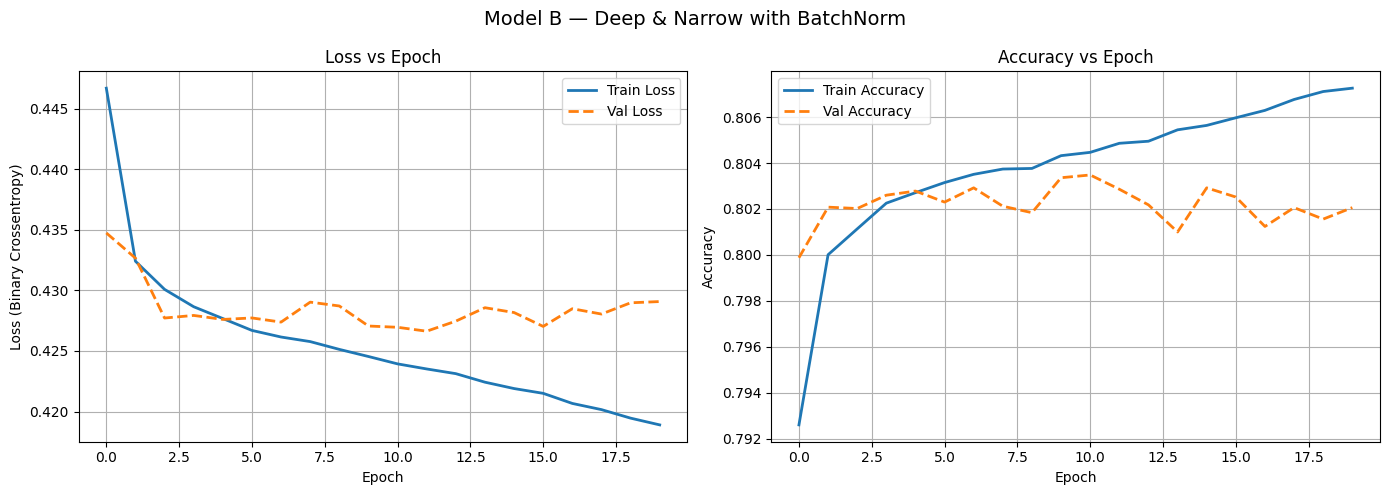

In [21]:
# --- Model B: Deep & Narrow with Batch Normalization ---
# BatchNormalization normalizes layer inputs to zero mean/unit variance
# during each mini-batch. This:
#   - Accelerates training (allows higher learning rates)
#   - Acts as regularization
#   - Helps with vanishing gradients in deep networks

model_B = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
], name="Deep_Narrow_BatchNorm")

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_B.summary()

hist_B = model_B.fit(
    X_Train_All_s, y_Train,
    validation_data=(X_Test_All_s, y_Test),
    epochs=20, batch_size=1024, verbose=1
)
plot_history(hist_B, title="Model B — Deep & Narrow with BatchNorm")

Model: "SGD_Momentum_Tanh"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 300)            │         5,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,601 (728.91 KB)

 Trainable params: 186,601 (728.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7839 - loss: 0.4631 - val_accuracy: 0.7920 - val_loss: 0.4485
Epoch 2/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7912 - loss: 0.4493 - val_accuracy: 0.7934 - val_loss: 0.4453
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7929 - loss: 0.4459 - val_accuracy: 0.7954 - val_loss: 0.4422
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7961 - loss: 0.4394 - val_accuracy: 0.7983 - val_loss: 0.4334
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7990 - loss: 0.4343 - val_accuracy: 0.7988 - val_loss: 0.4319
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8000 - loss: 0.4332 - val_accuracy: 0.8005 - val_loss: 0.4305
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8002 - loss: 0.4326 - val_accuracy: 0.7998 - val_loss: 0.4310
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8002 - loss: 0.4322 - val_accuracy: 0.

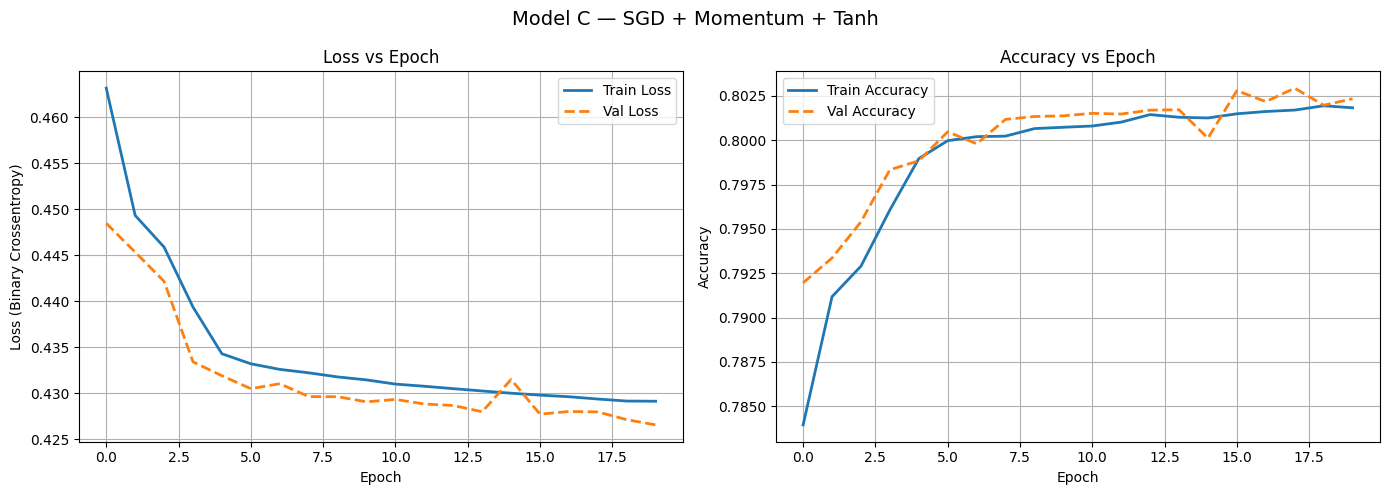

In [22]:
# --- Model C: Different optimizer (SGD + momentum) ---
# Adam adapts learning rates per parameter; SGD with momentum is simpler
# but can sometimes generalize better (flatter minima).
# We also try tanh activations instead of ReLU for variety.

model_C = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(300, activation='tanh'),
    layers.Dense(300, activation='tanh'),
    layers.Dense(300, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
], name="SGD_Momentum_Tanh")

sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_C.compile(optimizer=sgd, loss='binary_crossentropy', metrics=['accuracy'])
model_C.summary()

hist_C = model_C.fit(
    X_Train_All_s, y_Train,
    validation_data=(X_Test_All_s, y_Test),
    epochs=20, batch_size=1024, verbose=1
)
plot_history(hist_C, title="Model C — SGD + Momentum + Tanh")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


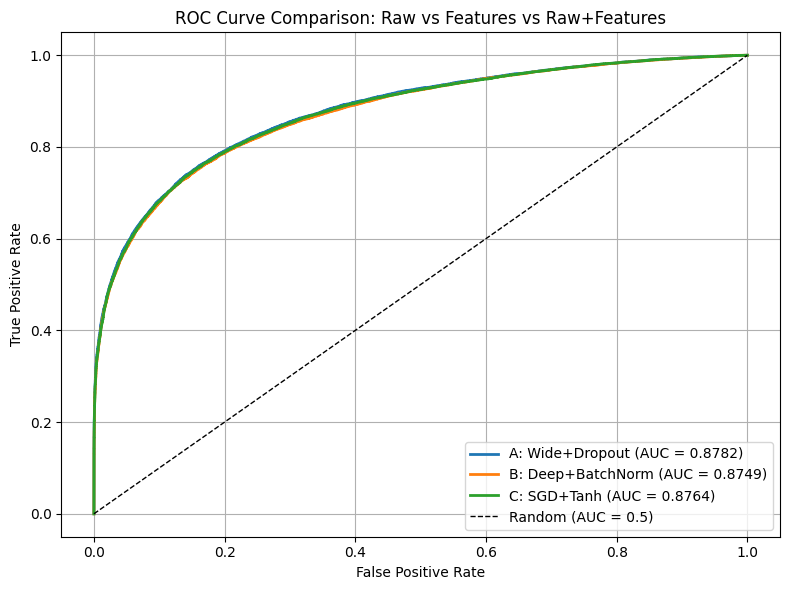

In [23]:
# --- Compare all 3 architectures with ROC curves ---
models_ex3 = {
    "A: Wide+Dropout":    model_A,
    "B: Deep+BatchNorm":  model_B,
    "C: SGD+Tanh":        model_C,
}
X_tests_ex3 = {label: X_Test_All_s for label in models_ex3}

plot_roc_curves(models_ex3, X_tests_ex3, y_Test)

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [24]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# We use the scaled all-variable arrays throughout for fair comparison.
# Traditional sklearn models don't require scaling but it doesn't hurt.

# --- Train Lab 8 models ---
print("Training Gradient Boosted Trees...")
gbt = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbt.fit(X_Train_All_s, y_Train)

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_Train_All_s, y_Train)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_Train_All_s, y_Train)

Training Gradient Boosted Trees...
Training Random Forest...
Training Logistic Regression...


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [25]:
# --- Identify best DNN from Exercise 3 ---
# Evaluate AUC for each Ex3 model to pick best:

def get_auc(model, X_test, y_test, is_keras=True):
    if is_keras:
        y_score = model.predict(X_test, batch_size=2048).ravel()
    else:
        y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    return auc(fpr, tpr)

auc_A = get_auc(model_A, X_Test_All_s, y_Test)
auc_B = get_auc(model_B, X_Test_All_s, y_Test)
auc_C = get_auc(model_C, X_Test_All_s, y_Test)
print(f"AUC — Model A: {auc_A:.4f}, Model B: {auc_B:.4f}, Model C: {auc_C:.4f}")

# Pick the best (adjust this line based on actual results)
best_dnn_label, best_dnn = max(
    [("DNN-A (Wide+Dropout)", model_A),
     ("DNN-B (Deep+BatchNorm)", model_B),
     ("DNN-C (SGD+Tanh)", model_C)],
    key=lambda x: get_auc(x[1], X_Test_All_s, y_Test)
)
print(f"Best DNN: {best_dnn_label}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
AUC — Model A: 0.8782, Model B: 0.8749, Model C: 0.8764
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best DNN: DNN-A (Wide+Dropout)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


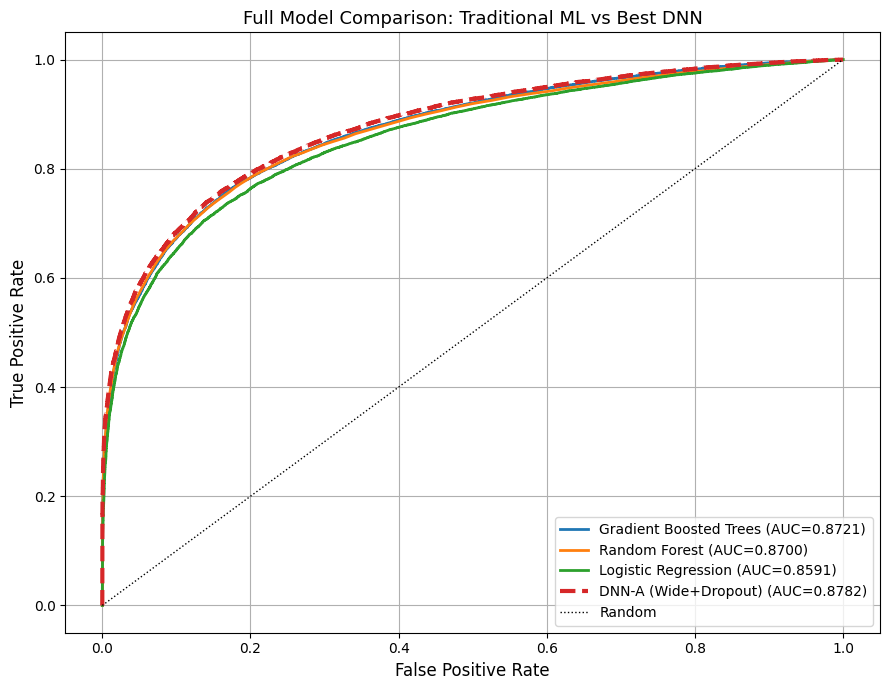

In [26]:
# --- Final ROC comparison: all models together ---

plt.figure(figsize=(9, 7))

# Traditional ML models
for label, clf in [("Gradient Boosted Trees", gbt),
                   ("Random Forest", rf),
                   ("Logistic Regression", lr)]:
    y_score = clf.predict_proba(X_Test_All_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_Test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.4f})")

# Best DNN
y_score_dnn = best_dnn.predict(X_Test_All_s, batch_size=2048).ravel()
fpr_dnn, tpr_dnn, _ = roc_curve(y_Test, y_score_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)
plt.plot(fpr_dnn, tpr_dnn, linewidth=3, linestyle='--',
         label=f"{best_dnn_label} (AUC={auc_dnn:.4f})")

plt.plot([0,1],[0,1],'k:', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Full Model Comparison: Traditional ML vs Best DNN', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()